In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import chi2
from scipy.stats import shapiro, skew, kurtosis, norm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.optimize import minimize

# Persiapan Data

### a.	Integrasi Data Saham

In [2]:
import pandas as pd

# Upload Data

file_path = r"D:\Semester 1-7\SKRIPSI\5. Data\Data 2023-2025\stocks_data_2023-2025.xlsx"

df_raw = pd.concat(
    pd.read_excel(file_path, sheet_name=None),
    ignore_index=True
)

df_raw["Date"] = pd.to_datetime(df_raw["Date"])

In [3]:
# Pemilihan Kolom

df_stock_clean = df_raw[
    ["Date", "Adj Close", "Volume", "Ticker"]
].copy()

df_stock_clean = df_stock_clean.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

### b.	Pemeriksaan Missing Value dan Konsistensi Data

In [4]:
print("=== MISSING VALUE PER KOLOM ===")
print(df_stock_clean.isna().sum())
print("\nTotal missing value:", df_stock_clean.isna().sum().sum())

=== MISSING VALUE PER KOLOM ===
Date         0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

Total missing value: 0


In [5]:
rows_per_ticker = df_stock_clean.groupby("Ticker").size()

print("\n=== JUMLAH BARIS PER TICKER ===")
print(rows_per_ticker)

print("\nApakah semua ticker jumlah baris sama?")
print(rows_per_ticker.nunique() == 1)


=== JUMLAH BARIS PER TICKER ===
Ticker
ACES    712
ADRO    712
AKRA    712
AMRT    712
ANTM    712
ASII    712
BBCA    712
BBNI    712
BBRI    712
BBTN    712
BMRI    712
BRPT    712
CPIN    712
EXCL    712
GOTO    712
ICBP    712
INCO    712
INDF    712
INKP    712
ITMG    712
KLBF    712
MDKA    712
MEDC    712
PGAS    712
PTBA    712
SMGR    712
TLKM    712
TOWR    712
UNTR    712
UNVR    712
dtype: int64

Apakah semua ticker jumlah baris sama?
True


In [6]:
all_dates = set(df_stock_clean["Date"].unique())

missing_dates = {}
for ticker in df_stock_clean["Ticker"].unique():
    ticker_dates = set(df_stock_clean.loc[df_stock_clean["Ticker"] == ticker, "Date"])
    diff = sorted(all_dates - ticker_dates)
    if diff:
        missing_dates[ticker] = diff

print("\n=== TANGGAL YANG TIDAK ADA DI MASING-MASING TICKER ===")
print(missing_dates)


=== TANGGAL YANG TIDAK ADA DI MASING-MASING TICKER ===
{}


### c.	Pemeriksaan Hari Libur dan Volume Perdagangan

In [7]:
zero_volume = df_stock_clean[df_stock_clean["Volume"] == 0]

print("\n=== DATA DENGAN VOLUME = 0 ===")
print(zero_volume[["Date", "Ticker", "Volume"]])

print("\nJumlah baris volume = 0:", len(zero_volume))


=== DATA DENGAN VOLUME = 0 ===
            Date Ticker  Volume
1515  2023-05-24   AKRA       0
8635  2023-05-24   CPIN       0
10216 2024-01-15   GOTO       0
10261 2024-03-25   GOTO       0
10262 2024-03-26   GOTO       0
12907 2023-05-24   INKP       0
13619 2023-05-24   ITMG       0
20739 2023-05-24   UNVR       0

Jumlah baris volume = 0: 8


In [8]:
df_stock_clean

,Date,Adj Close,Volume,Ticker
0,2023-01-02,436.19,43569200,ACES
1,2023-01-03,436.19,257788700,ACES
2,2023-01-04,427.63,74033400,ACES
3,2023-01-05,417.37,88532700,ACES
4,2023-01-06,419.08,73117700,ACES
...,...,...,...,...
21355,2025-12-22,2700.00,22606200,UNVR
21356,2025-12-23,2610.00,17218500,UNVR
21357,2025-12-24,2600.00,10056300,UNVR
21358,2025-12-29,2600.00,13763200,UNVR


# Statistika Deskriptif

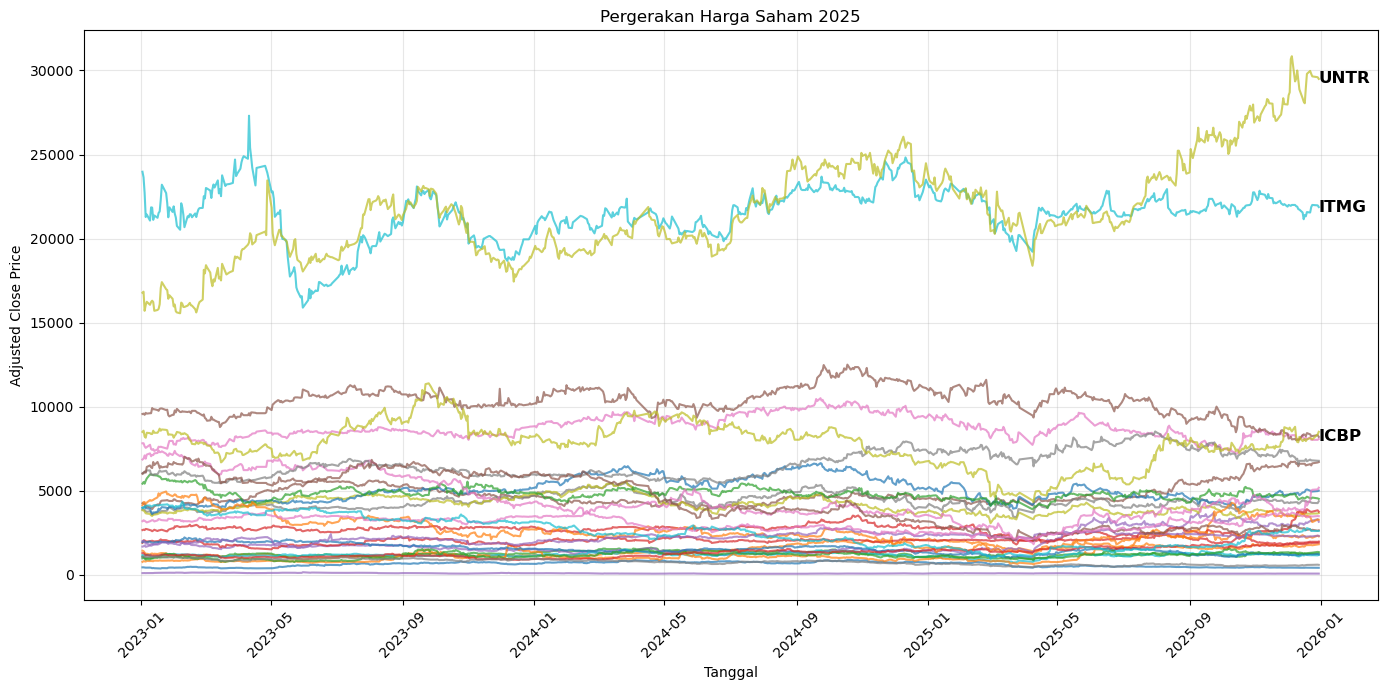

In [9]:
# Hitung harga rata-rata tiap saham
avg_price = df_stock_clean.groupby('Ticker')['Adj Close'].mean().sort_values(ascending=False)

# Ambil 3 saham dengan harga rata-rata tertinggi
top_3 = avg_price.head(3).index.tolist()


# Plot semua saham
plt.figure(figsize=(14, 7))
tickers = df_stock_clean['Ticker'].unique()

for ticker in tickers:
    data = df_stock_clean[df_stock_clean['Ticker'] == ticker]
    plt.plot(data['Date'], data['Adj Close'], label=ticker if ticker in top_3 else "", alpha=0.7)


# Tambahkan label pada garis top 3
for ticker in top_3:
    data = df_stock_clean[df_stock_clean['Ticker'] == ticker]
    plt.text(
        x=data['Date'].iloc[-1], 
        y=data['Adj Close'].iloc[-1], 
        s=ticker, 
        fontsize=12, 
        fontweight='bold',
        va='center'
    )

# Styling plot
plt.title("Pergerakan Harga Saham 2025")
plt.xlabel("Tanggal")
plt.ylabel("Adjusted Close Price")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# Statistik deskriptif dasar per saham

desc_stats = df_stock_clean.groupby("Ticker")["Adj Close"].describe()

print("=== STATISTIK DESKRIPTIF HARGA SAHAM ===")
desc_stats.head()

=== STATISTIK DESKRIPTIF HARGA SAHAM ===


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
ACES,712.0,611.881390,146.147507,367.76,462.9950,650.930,736.6825,878.18
ADRO,712.0,1474.335379,327.271921,897.73,1166.9125,1476.810,1747.8700,2254.58
AKRA,712.0,1232.842458,138.810249,832.22,1125.5100,1223.520,1340.0475,1604.75
AMRT,712.0,2619.417065,344.375908,1785.00,2399.5900,2726.250,2833.7400,3523.52
ANTM,712.0,1873.657949,675.700944,1152.61,1419.3300,1588.815,1935.0900,3670.00


In [11]:
# Hitung return harian

df_stock_clean["Return"] = np.log(
    df_stock_clean["Adj Close"] /
    df_stock_clean.groupby("Ticker")["Adj Close"].shift(1)
)

# Hapus NaN hasil pct_change
df_return = df_stock_clean.dropna()

# Statistik return
return_stats = df_return.groupby("Ticker")["Return"].describe()

print("=== STATISTIK DESKRIPTIF RETURN ===")
print(return_stats)

=== STATISTIK DESKRIPTIF RETURN ===
        count      mean       std       min       25%       50%       75%  \
Ticker                                                                      
ACES    711.0 -0.000087  0.026468 -0.164000 -0.013638  0.000000  0.012600   
ADRO    711.0  0.000336  0.027276 -0.282865 -0.012441  0.000000  0.012807   
AKRA    711.0  0.000217  0.023557 -0.121217 -0.010774  0.000000  0.010732   
AMRT    711.0 -0.000416  0.022012 -0.093436 -0.012632  0.000000  0.010848   
ANTM    711.0  0.000891  0.025509 -0.155168 -0.012271  0.000000  0.012976   
ASII    711.0  0.000638  0.016518 -0.093685 -0.009113  0.000000  0.008939   
BBCA    711.0  0.000045  0.014720 -0.089153 -0.008559  0.000000  0.007693   
BBNI    711.0  0.000170  0.019016 -0.083383 -0.009153  0.000000  0.009390   
BBRI    711.0 -0.000066  0.018628 -0.106733 -0.009674  0.000000  0.009302   
BBTN    711.0  0.000007  0.022290 -0.102760 -0.011182 -0.003740  0.009754   
BMRI    711.0  0.000321  0.019296 -0.107

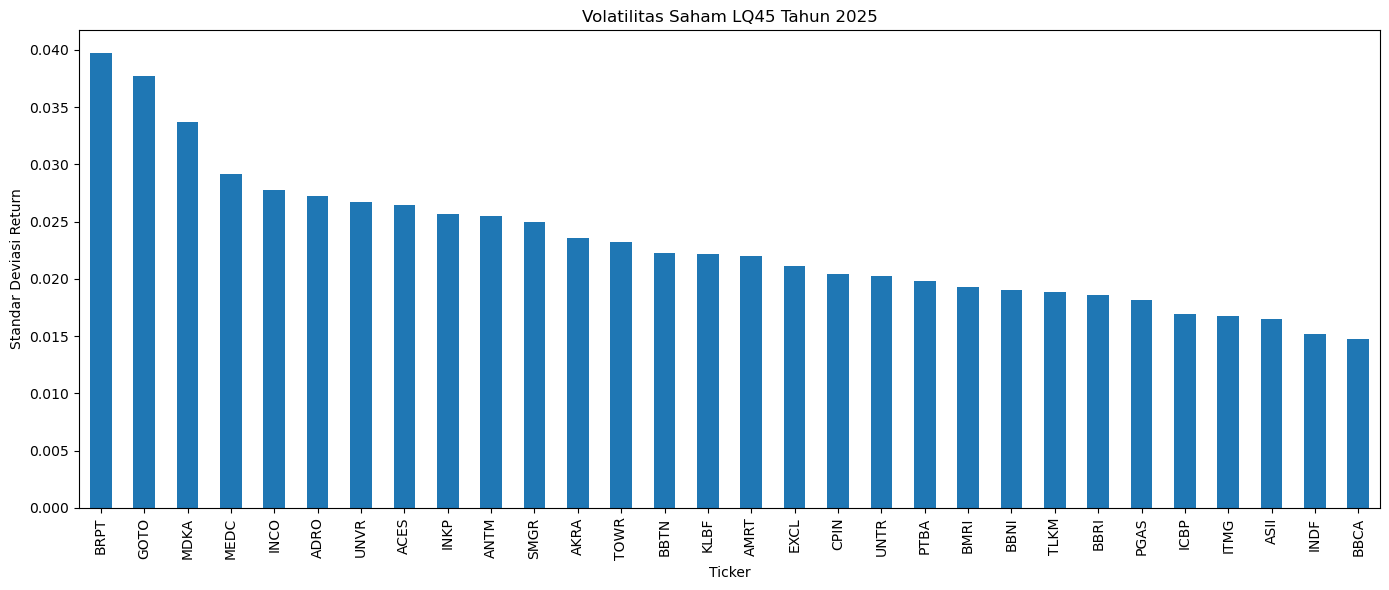

In [12]:
# Volatilitas per saham

volatility = df_return.groupby("Ticker")["Return"].std().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

volatility.plot(kind="bar")

plt.title("Volatilitas Saham LQ45 Tahun 2025")
plt.xlabel("Ticker")
plt.ylabel("Standar Deviasi Return")

plt.tight_layout()
plt.show()


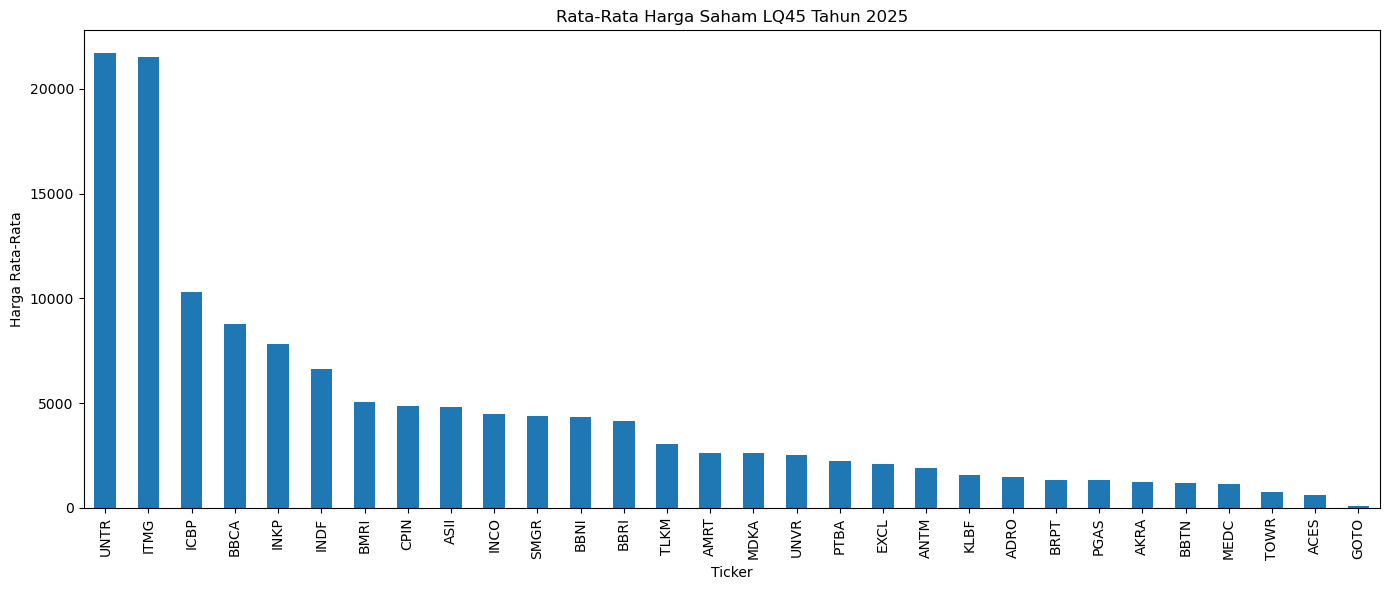

In [13]:
# Rata-rata harga saham

avg_price = df_stock_clean.groupby("Ticker")["Adj Close"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

avg_price.plot(kind="bar")

plt.title("Rata-Rata Harga Saham LQ45 Tahun 2025")
plt.xlabel("Ticker")
plt.ylabel("Harga Rata-Rata")

plt.tight_layout()
plt.show()


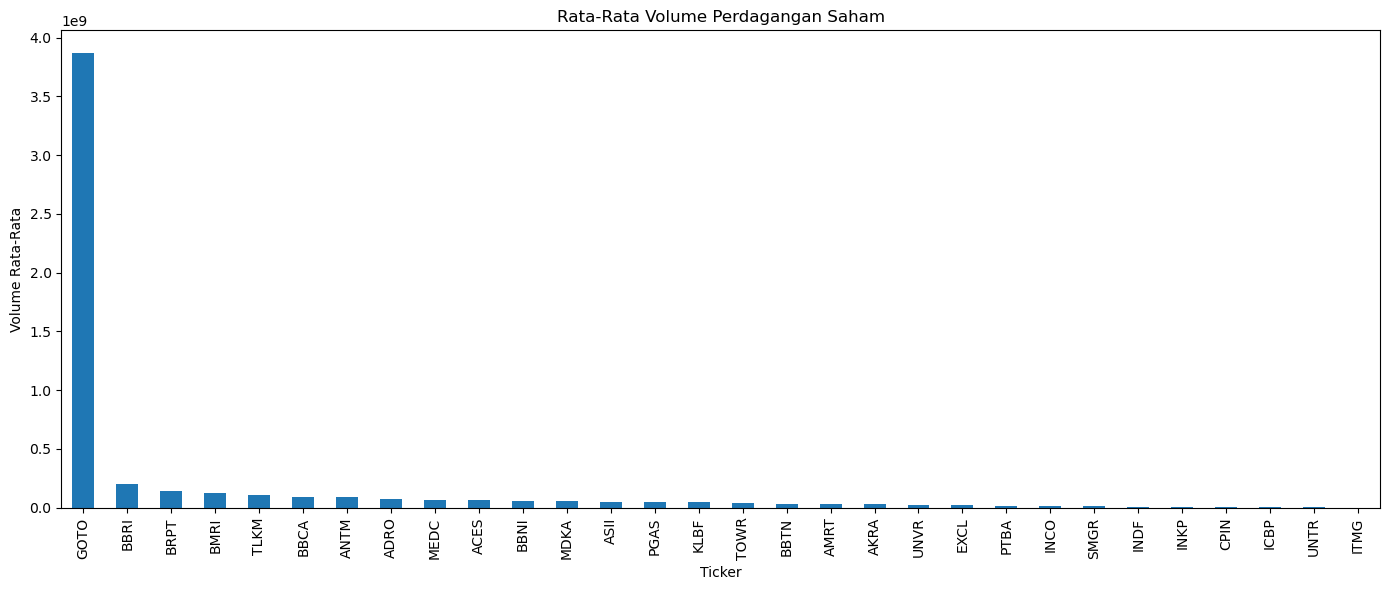

In [14]:
# Rata-rata volume

avg_volume = df_stock_clean.groupby("Ticker")["Volume"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

avg_volume.plot(kind="bar")

plt.title("Rata-Rata Volume Perdagangan Saham")
plt.xlabel("Ticker")
plt.ylabel("Volume Rata-Rata")

plt.tight_layout()
plt.show()


# Pembentukan Variabel Penelitian

### Perhitungan Return Saham

In [15]:
# Hitung log return harian
df_stock_clean["LogReturn"] = (
    df_stock_clean
    .groupby("Ticker")["Adj Close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

### Perhitungan Expected Return, Risiko, dan Volume Perdagangan Saham

In [16]:
df_variables = (
    df_stock_clean
    .groupby("Ticker")
    .agg(
        ExpectedReturn=("LogReturn", "mean"),
        Variance=("LogReturn", "var"),
        AvgTradingVolume=("Volume", "mean")
    )
    .reset_index()
)


In [17]:
# Pilih 3 saham dan buang NaN
selected_stocks = ["ACES", "ADRO", "AKRA"]

df_logreturn_3 = (
    df_stock_clean[df_stock_clean["Ticker"].isin(selected_stocks)]
    [["Date", "Ticker", "LogReturn"]]
    .dropna()
)

# Ubah jadi format kolom saham
df_pivot = df_logreturn_3.pivot(
    index="Date",
    columns="Ticker",
    values="LogReturn"
)

# Reset index supaya Date jadi kolom biasa
df_pivot = df_pivot.reset_index()

df_pivot

Ticker,Date,ACES,ADRO,AKRA
0,2023-01-03,0.000000,-0.019692,-0.025595
1,2023-01-04,-0.019820,-0.064540,-0.045468
2,2023-01-05,-0.024285,-0.062514,-0.047624
3,2023-01-06,0.004089,0.012821,0.032003
4,2023-01-09,0.004072,-0.035661,-0.003946
...,...,...,...,...
706,2025-12-22,-0.004819,-0.002637,0.008097
707,2025-12-23,-0.004843,0.005261,0.008032
708,2025-12-24,0.000000,-0.007905,0.000000
709,2025-12-29,0.000000,0.028688,0.000000


In [18]:
df_variables

,Ticker,ExpectedReturn,Variance,AvgTradingVolume
0,ACES,-0.000087,0.000701,6.290152e+07
1,ADRO,0.000336,0.000744,7.582068e+07
2,AKRA,0.000217,0.000555,2.912999e+07
3,AMRT,-0.000416,0.000485,2.948757e+07
4,ANTM,0.000891,0.000651,9.031035e+07
5,ASII,0.000638,0.000273,5.009064e+07
6,BBCA,0.000045,0.000217,9.537778e+07
7,BBNI,0.000170,0.000362,5.872952e+07
8,BBRI,-0.000066,0.000347,2.024387e+08
9,BBTN,0.000007,0.000497,3.152546e+07


# Exploratory Data Analysis (EDA)

### a.	Analisis Distribusi Return Saham

In [19]:
results = []

for ticker, grp in df_stock_clean.groupby("Ticker"):
    returns = grp["LogReturn"].dropna()
    if len(returns) < 30:
        continue

    stat, p = shapiro(returns)

    results.append({
        "Ticker": ticker,
        "SW_Statistic": stat,
        "p_value": p,
        "Normal": "Yes" if p > 0.05 else "No"
    })

df_sw = pd.DataFrame(results)
df_sw

,Ticker,SW_Statistic,p_value,Normal
0,ACES,0.939743,2.263486e-16,No
1,ADRO,0.853672,3.924727e-25,No
2,AKRA,0.921127,8.114170e-19,No
3,AMRT,0.971685,1.694329e-10,No
4,ANTM,0.960549,6.726950e-13,No
5,ASII,0.964687,4.584185e-12,No
6,BBCA,0.966575,1.155702e-11,No
7,BBNI,0.965683,7.435051e-12,No
8,BBRI,0.967488,1.830031e-11,No
9,BBTN,0.941069,3.535996e-16,No


### b.	Identifikasi Outlier

In [20]:
df_outlier_check = df_variables.copy()

cols = ["ExpectedReturn", "Variance", "AvgTradingVolume"]

for col in cols:
    Q1 = df_outlier_check[col].quantile(0.25)
    Q3 = df_outlier_check[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_outlier_check[f'Outlier_{col}'] = (
        (df_outlier_check[col] < lower) |
        (df_outlier_check[col] > upper)
    )

df_outliers = df_outlier_check[
    df_outlier_check[[f'Outlier_{c}' for c in cols]].any(axis=1)
]
df_outliers


,Ticker,ExpectedReturn,Variance,AvgTradingVolume,Outlier_ExpectedReturn,Outlier_Variance,Outlier_AvgTradingVolume
8,BBRI,-0.000066,0.000347,2.024387e+08,False,False,True
11,BRPT,0.002050,0.001578,1.394325e+08,True,True,False
14,GOTO,-0.000526,0.001422,3.868121e+09,False,True,True


### c. Penyaringan Saham Berdasarkan Expected Return

In [21]:
# Filter saham dengan Expected Return positif
df_filtered = df_variables[df_variables["ExpectedReturn"] > 0].copy()
df_filtered

,Ticker,ExpectedReturn,Variance,AvgTradingVolume
1,ADRO,0.000336,0.000744,7.582068e+07
2,AKRA,0.000217,0.000555,2.912999e+07
4,ANTM,0.000891,0.000651,9.031035e+07
5,ASII,0.000638,0.000273,5.009064e+07
6,BBCA,0.000045,0.000217,9.537778e+07
7,BBNI,0.000170,0.000362,5.872952e+07
9,BBTN,0.000007,0.000497,3.152546e+07
10,BMRI,0.000321,0.000372,1.229068e+08
11,BRPT,0.002050,0.001578,1.394325e+08
13,EXCL,0.000963,0.000448,2.010874e+07


In [22]:
tickers_selected = ["MDKA", "ANTM", "BRPT"]
df_filtered[df_filtered["Ticker"].isin(tickers_selected)]

,Ticker,ExpectedReturn,Variance,AvgTradingVolume
4,ANTM,0.000891,0.000651,9.031035e+07
11,BRPT,0.002050,0.001578,1.394325e+08


In [23]:
# Pilih variabel
features = ['ExpectedReturn', 'Variance', 'AvgTradingVolume']
X = df_filtered[features].values

# Mean vector & Covariance matrix
mean_vec = np.mean(X, axis=0)
cov_matrix = np.cov(X, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Hitung Mahalanobis Distance
def mahalanobis_d2(x, mean_vec, inv_cov_matrix):
    diff = x - mean_vec
    d2 = np.dot(np.dot(diff, inv_cov_matrix), diff.T)
    return d2

# Hitung D² untuk semua saham
df_filtered['Mahalanobis_D2'] = np.array(
    [mahalanobis_d2(x, mean_vec, inv_cov_matrix) for x in X]
)

# Hitung p-value
df_filtered['p_value'] = 1 - chi2.cdf(
    df_filtered['Mahalanobis_D2'],
    df=len(features)
)

# Susun tabel seperti artikel
df_mahalanobis = df_filtered[['Ticker', 'Mahalanobis_D2', 'p_value']].copy()

# Urutkan dari terbesar (biar outlier terlihat jelas di atas)
df_mahalanobis = df_mahalanobis.sort_values(
    by='Mahalanobis_D2',
    ascending=False
).reset_index(drop=True)

print(df_mahalanobis)

   Ticker  Mahalanobis_D2   p_value
0    BRPT       12.061744  0.007175
1    INKP        4.763708  0.189940
2    BMRI        3.981182  0.263503
3    EXCL        3.756450  0.288993
4    UNTR        3.554170  0.313804
5    BBCA        3.113517  0.374452
6    TLKM        2.976015  0.395338
7    ASII        2.164794  0.538916
8    MEDC        2.098760  0.552164
9    BBTN        1.672849  0.642987
10   ADRO        1.612277  0.656609
11   INDF        1.550937  0.670565
12   ANTM        1.137172  0.768109
13   PGAS        1.104708  0.775938
14   AKRA        1.103954  0.776120
15   PTBA        0.893610  0.826969
16   BBNI        0.454153  0.928842


In [24]:
chi_critical = chi2.ppf(0.95, df=len(features))
print("Nilai kritis Chi-Square (α=0.05; df=3):", chi_critical)

Nilai kritis Chi-Square (α=0.05; df=3): 7.814727903251179


# Mean Shift

### a. Standarisasi Variabel Penelitian

In [25]:
features = ['ExpectedReturn', 'Variance', 'AvgTradingVolume']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered[features])

print("=== Hasil Standarisasi Python (X_scaled) ===")
print(X_scaled)


# Perhitungan manual z-score untuk ExpectedReturn
x_admr = df_filtered.iloc[0]['ExpectedReturn']  # nilai ExpectedReturn baris pertama  
mean_er = df_filtered['ExpectedReturn'].mean()  # mean seluruh saham
std_er = df_filtered['ExpectedReturn'].std(ddof=0)  # standar deviasi seluruh saham

z_admr = (x_admr - mean_er) / std_er

print("\n=== Perhitungan Manual z-score untuk ADMR ===")
print(f"Nilai asli ExpectedReturn ADMR: {x_admr}")
print(f"Rata-rata ExpectedReturn seluruh saham: {mean_er}")
print(f"Standar deviasi ExpectedReturn seluruh saham: {std_er}")
print(f"Z-score ADRO: {z_admr}")

=== Hasil Standarisasi Python (X_scaled) ===
[[-0.26470819  0.6930869   0.4550003 ]
 [-0.50608825  0.09504115 -0.68278337]
 [ 0.85902913  0.39807616  0.80809225]
 [ 0.34703414 -0.79728811 -0.17200305]
 [-0.85384944 -0.97489615  0.93157812]
 [-0.60152639 -0.516486    0.03851385]
 [-0.93000156 -0.08871107 -0.62440912]
 [-0.29634523 -0.48249697  1.60242044]
 [ 3.20303821  3.33286235  2.00512576]
 [ 1.0044056  -0.24368332 -0.90261793]
 [-0.62093904 -0.93151854 -1.18203523]
 [-0.94283997  0.4170686  -1.2164429 ]
 [-0.02449043  1.03511395  0.23455031]
 [ 0.18377206 -0.62048729 -0.27006892]
 [-0.5249293  -0.41550136 -0.94601515]
 [-0.69349987 -0.53760156  1.20131856]
 [ 0.66193853 -0.36257873 -1.28022392]]

=== Perhitungan Manual z-score untuk ADMR ===
Nilai asli ExpectedReturn ADMR: 0.00033616693463880406
Rata-rata ExpectedReturn seluruh saham: 0.00046696102915520565
Standar deviasi ExpectedReturn seluruh saham: 0.0004941067071554753
Z-score ADRO: -0.26470819485404395


### b. Pembentukan Matriks Fitur

In [26]:
print("Tahap (b) Pembentukan Matriks Fitur")
print("Dimensi matriks fitur (jumlah saham x jumlah variabel):", X_scaled.shape)

Tahap (b) Pembentukan Matriks Fitur
Dimensi matriks fitur (jumlah saham x jumlah variabel): (17, 3)


### c. Estimasi Bandwidth untuk Mean Shift

In [27]:
quantile_range = np.arange(0.10, 0.80, 0.05)
results = []

print("Tahap (c) Estimasi Bandwidth untuk Mean Shift")
for q in quantile_range:
    try:
        bandwidth = estimate_bandwidth(
            X_scaled,
            quantile=q,
            n_samples=len(X_scaled)
        )

        if bandwidth <= 0:
            continue

        # Evaluasi sementara tanpa menyimpan label final
        ms = MeanShift(bandwidth=bandwidth, bin_seeding=False)
        labels = ms.fit_predict(X_scaled)
        n_clusters = len(np.unique(labels))

        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
            dbi = davies_bouldin_score(X_scaled, labels)
            chi = calinski_harabasz_score(X_scaled, labels)
        else:
            sil = np.nan
            dbi = np.nan
            chi = np.nan

        results.append({
            "Quantile": q,
            "Bandwidth": bandwidth,
            "Jumlah Klaster": n_clusters,
            "Silhouette": sil,
            "DaviesBouldin": dbi,
            "CalinskiHarabasz": chi
        })

    except Exception as e:
        print(f"Gagal pada quantile {q:.2f}: {e}")

df_eval = pd.DataFrame(results)
print("\nTabel Evaluasi Parameter Bandwidth:")
print(df_eval.round(4))

Tahap (c) Estimasi Bandwidth untuk Mean Shift

Tabel Evaluasi Parameter Bandwidth:
    Quantile  Bandwidth  Jumlah Klaster  Silhouette  DaviesBouldin  \
0       0.15     0.7650               8      0.3713         0.3953   
1       0.20     1.1264               5      0.3451         0.5021   
2       0.25     1.3214               4      0.3868         0.6157   
3       0.30     1.5285               2      0.6446         0.2183   
4       0.35     1.5285               2      0.6446         0.2183   
5       0.40     1.6084               2      0.6446         0.2183   
6       0.45     1.7242               2      0.6446         0.2183   
7       0.50     1.8222               2      0.6446         0.2183   
8       0.55     1.8834               2      0.6446         0.2183   
9       0.60     2.0058               2      0.6446         0.2183   
10      0.65     2.1311               2      0.6446         0.2183   
11      0.70     2.1311               2      0.6446         0.2183   
12     

### d. Pemilihan Bandwidth Optimal

In [28]:
# Pastikan ada baris valid
if df_eval['Silhouette'].notna().any():
    best_row = df_eval.loc[df_eval['Silhouette'].idxmax()]
    best_quantile = best_row['Quantile']
    best_bandwidth = best_row['Bandwidth']

    print("\nTahap (d) Pemilihan Bandwidth Optimal")
    print(f"Quantile terpilih   : {best_quantile}")
    print(f"Bandwidth terpilih  : {best_bandwidth}")
    print(f"Jumlah klaster      : {best_row['Jumlah Klaster']}")
    print(f"Silhouette Score    : {best_row['Silhouette']}")
    print(f"Davies Bouldin      : {best_row['DaviesBouldin']}")
    print(f"Calinski Harabasz   : {best_row['CalinskiHarabasz']}")
else:
    print("Tidak ada baris evaluasi valid untuk pemilihan bandwidth.")


Tahap (d) Pemilihan Bandwidth Optimal
Quantile terpilih   : 0.30000000000000004
Bandwidth terpilih  : 1.5285201656489285
Jumlah klaster      : 2.0
Silhouette Score    : 0.6445800790704257
Davies Bouldin      : 0.21826767147368778
Calinski Harabasz   : 16.8414359989936


In [29]:
manual_quantile = 0.25  # quantile yang kamu inginkan

# Cari baris yang quantilenya dekat dengan manual_quantile
best_row = df_eval[np.isclose(df_eval['Quantile'], manual_quantile)].iloc[0]

best_quantile = best_row['Quantile']
best_bandwidth = best_row['Bandwidth']

print("\nTahap (d) Pemilihan Bandwidth Manual")
print(f"Quantile terpilih   : {best_quantile}")
print(f"Bandwidth terpilih  : {best_bandwidth}")
print(f"Jumlah klaster      : {best_row['Jumlah Klaster']}")
print(f"Silhouette Score    : {best_row['Silhouette']}")
print(f"Davies Bouldin      : {best_row['DaviesBouldin']}")
print(f"Calinski Harabasz   : {best_row['CalinskiHarabasz']}")


Tahap (d) Pemilihan Bandwidth Manual
Quantile terpilih   : 0.25000000000000006
Bandwidth terpilih  : 1.3213963976572014
Jumlah klaster      : 4.0
Silhouette Score    : 0.3867762755485358
Davies Bouldin      : 0.6157063861280221
Calinski Harabasz   : 19.36041434880126


### e. Klasterisasi dengan Mean Shift (KDE dan konvergensi centroid)

In [30]:
ms_final = MeanShift(bandwidth=best_bandwidth, bin_seeding=False)
labels = ms_final.fit_predict(X_scaled)

df_filtered['Cluster'] = labels

print("Tahap (e) Klasterisasi dengan Mean Shift")
print("Proses pergeseran centroid berbasis KDE selesai")
print("Centroid telah mencapai titik konvergen")
print("Jumlah klaster akhir:", df_filtered['Cluster'].nunique())

Tahap (e) Klasterisasi dengan Mean Shift
Proses pergeseran centroid berbasis KDE selesai
Centroid telah mencapai titik konvergen
Jumlah klaster akhir: 4


In [31]:
print("\n=== Titik Konvergen (Centroid Akhir) ===")
centroids = ms_final.cluster_centers_

for i, center in enumerate(centroids):
    print(f"Centroid Klaster {i}: {center}")

print("\nJumlah Titik Konvergen:", len(centroids))


=== Titik Konvergen (Centroid Akhir) ===
Centroid Klaster 0: [-0.19291742 -0.34641447 -0.72380857]
Centroid Klaster 1: [-0.61130523 -0.62787017  0.94345774]
Centroid Klaster 2: [0.1899435  0.708759   0.49921429]
Centroid Klaster 3: [3.20303821 3.33286235 2.00512576]

Jumlah Titik Konvergen: 4


### f. Evaluasi Kualitas Klasterisasi

In [32]:
silhouette_final = silhouette_score(X_scaled, labels)
dbi_final = davies_bouldin_score(X_scaled, labels)
chi_final = calinski_harabasz_score(X_scaled, labels)

print("Tahap (f) Evaluasi Kualitas Klasterisasi")
print(f"Silhouette Score        : {silhouette_final:.4f}")
print(f"Davies-Bouldin Index    : {dbi_final:.4f}")
print(f"Calinski-Harabasz Index : {chi_final:.4f}")

Tahap (f) Evaluasi Kualitas Klasterisasi
Silhouette Score        : 0.3868
Davies-Bouldin Index    : 0.6157
Calinski-Harabasz Index : 19.3604


### g. Analisis Karakteristik Klaster

In [33]:
# Menggabungkan data hasil klaster dengan volume perdagangan asli
df_filtered['AvgTradingVolume_Original'] = df_variables['AvgTradingVolume']
df_cluster_full = df_filtered.merge(
    df_filtered[['Ticker', 'AvgTradingVolume_Original']],
    on='Ticker',
    how='left'
)


# Menghitung karakteristik rata-rata tiap klaster
cluster_characteristics = (
    df_cluster_full
    .groupby('Cluster')
    .agg(
        Rata_Rata_Expected_Return=('ExpectedReturn', 'mean'),
        Rata_Rata_Varians=('Variance', 'mean'),
        Rata_Rata_Volume_Perdagangan=('AvgTradingVolume', 'mean'),  # atau kolom original
        Daftar_Saham=('Ticker', lambda x: ', '.join(sorted(x)))
    )
    .reset_index()
)
# Pembulatan hasil agar rapi
cluster_characteristics = cluster_characteristics.round(6)

# Menampilkan output tabel
pd.set_option('display.max_colwidth', None)
cluster_characteristics

,Cluster,Rata_Rata_Expected_Return,Rata_Rata_Varians,Rata_Rata_Volume_Perdagangan,Daftar_Saham
0,0,0.000372,0.000415,2.744645e+07,"AKRA, ASII, BBNI, BBTN, EXCL, INDF, INKP, PGAS, PTBA, UNTR"
1,1,0.000163,0.000315,1.082439e+08,"BBCA, BMRI, TLKM"
2,2,0.000561,0.000749,7.763507e+07,"ADRO, ANTM, MEDC"
3,3,0.002050,0.001578,1.394325e+08,BRPT


### g. Visualisasi Hasil Klasterisasi

Tahap (g) Visualisasi Hasil Klasterisasi


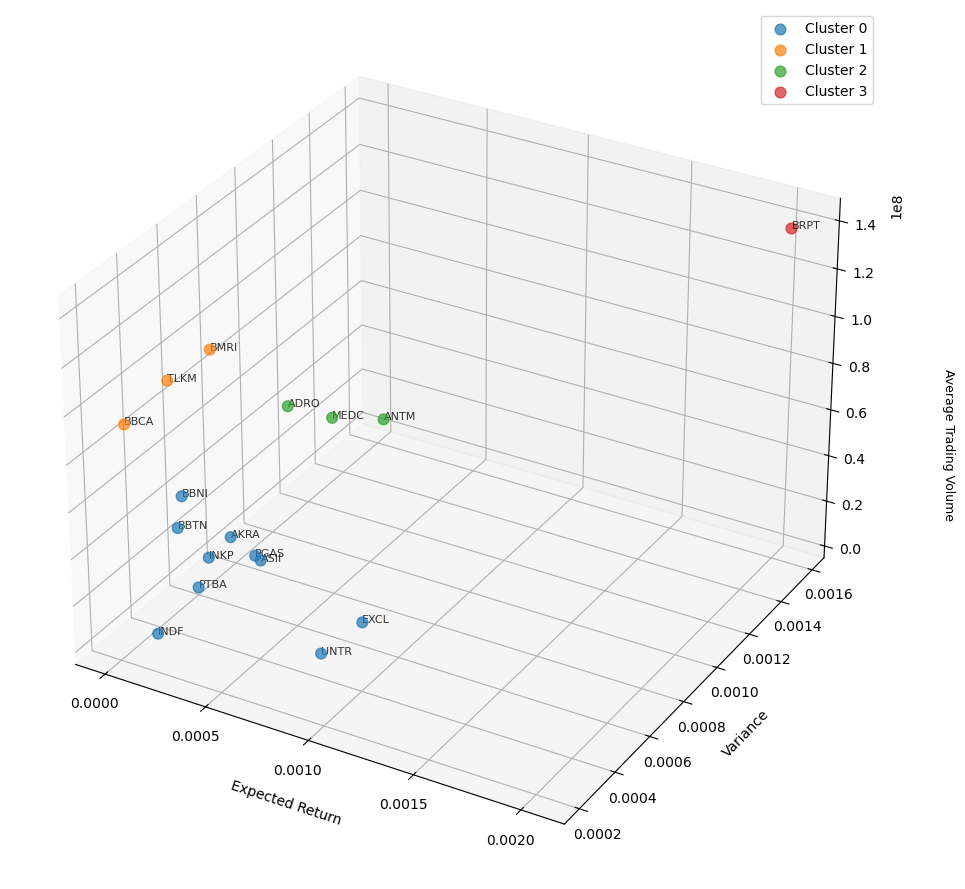

In [34]:
print("Tahap (g) Visualisasi Hasil Klasterisasi")

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

labels = df_filtered['Cluster'].values
tickers = df_filtered['Ticker'].values
unique_clusters = np.unique(labels)

for cluster in unique_clusters:
    idx = labels == cluster

    ax.scatter(
        df_filtered.loc[idx, 'ExpectedReturn'],
        df_filtered.loc[idx, 'Variance'],
        df_filtered.loc[idx, 'AvgTradingVolume'],
        label=f'Cluster {cluster}',
        s=60,
        alpha=0.7
    )

    for i in df_filtered.loc[idx].index:
        ax.text(
            df_filtered.loc[i, 'ExpectedReturn'],
            df_filtered.loc[i, 'Variance'],
            df_filtered.loc[i, 'AvgTradingVolume'],
            df_filtered.loc[i, 'Ticker'],
            fontsize=8,
            alpha=0.8
        )

ax.set_xlabel('Expected Return', labelpad=10)
ax.set_ylabel('Variance', labelpad=10)
ax.set_zlabel('')
fig.text(
    0.92, 0.5,
    'Average Trading Volume',
    rotation=-90,
    va='center',
    ha='center',
    fontsize=9
)

ax.legend()
plt.tight_layout()
plt.show()

In [35]:
print("\n=== Parameter Model Mean Shift Final ===")
print(ms_final.get_params())


=== Parameter Model Mean Shift Final ===
{'bandwidth': 1.3213963976572014, 'bin_seeding': False, 'cluster_all': True, 'max_iter': 300, 'min_bin_freq': 1, 'n_jobs': None, 'seeds': None}


In [36]:
print("\n=== Parameter Mean Shift yang Digunakan ===")
print(f"Bandwidth      : {ms_final.bandwidth}")
print(f"Bin Seeding    : {ms_final.bin_seeding}")
print(f"Cluster All    : {ms_final.cluster_all}")
print(f"Max Iter       : {ms_final.max_iter}")


=== Parameter Mean Shift yang Digunakan ===
Bandwidth      : 1.3213963976572014
Bin Seeding    : False
Cluster All    : True
Max Iter       : 300


In [37]:
print("\n=== Parameter Estimasi Bandwidth ===")
print(f"Rentang Quantile : 0.10 - 0.75")
print(f"Quantile Terpilih: {best_quantile}")
print(f"Jumlah Sampel    : {len(X_scaled)}")


=== Parameter Estimasi Bandwidth ===
Rentang Quantile : 0.10 - 0.75
Quantile Terpilih: 0.25000000000000006
Jumlah Sampel    : 17


# Pemilihan Saham berdasarkan Sharpe Ratio

In [38]:
import numpy as np
import pandas as pd

TRADING_DAYS = 236
risk_free_rate = 0.057291667

# Annualisasi return dan volatilitas
df_filtered['ExpReturn_Ann'] = df_filtered['ExpectedReturn'] * TRADING_DAYS
df_filtered['Vol_Ann'] = np.sqrt(df_filtered['Variance'] * TRADING_DAYS)

# Sharpe Ratio tahunan per saham
df_filtered['SharpeRatio_Ann'] = (
    (df_filtered['ExpReturn_Ann'] - risk_free_rate) /
    df_filtered['Vol_Ann']
)

# Urutkan Sharpe Ratio dalam tiap klaster
cluster_sharpe = (
    df_filtered[['Cluster', 'Ticker', 'SharpeRatio_Ann']]
    .sort_values(['Cluster', 'SharpeRatio_Ann'], ascending=[True, False])
)

print("Sharpe Ratio Saham dalam Tiap Klaster:")
print(cluster_sharpe)

# Pilih saham terbaik (Sharpe tertinggi) per klaster
best_sharpe = df_filtered.loc[
    df_filtered.groupby('Cluster')['SharpeRatio_Ann'].idxmax()
].reset_index(drop=True)

print("\nSaham Terbaik per Klaster (berdasarkan Sharpe Ratio):")
print(best_sharpe[['Cluster', 'Ticker', 'SharpeRatio_Ann']])

# Simpan ticker terpilih
best_tickers = best_sharpe['Ticker'].tolist()

Sharpe Ratio Saham dalam Tiap Klaster:
    Cluster Ticker  SharpeRatio_Ann
13        0   EXCL         0.523018
28        0   UNTR         0.418110
5         0   ASII         0.367993
23        0   PGAS         0.266902
2         0   AKRA        -0.016866
24        0   PTBA        -0.027237
7         0   BBNI        -0.058989
17        0   INDF        -0.083608
18        0   INKP        -0.144869
9         0   BBTN        -0.162185
10        1   BMRI         0.061917
26        1   TLKM        -0.096598
6         1   BBCA        -0.206313
4         2   ANTM         0.390635
22        2   MEDC         0.111622
1         2   ADRO         0.052608
11        3   BRPT         0.698648

Saham Terbaik per Klaster (berdasarkan Sharpe Ratio):
   Cluster Ticker  SharpeRatio_Ann
0        0   EXCL         0.523018
1        1   BMRI         0.061917
2        2   ANTM         0.390635
3        3   BRPT         0.698648


In [39]:
# Filter saham EXCL
excl_data = df_filtered[df_filtered['Ticker'] == 'EXCL'][['Ticker', 'ExpReturn_Ann', 'Vol_Ann']]

print("Expected Return Tahunan dan Volatilitas Tahunan untuk saham EXCL:")
print(excl_data)

Expected Return Tahunan dan Volatilitas Tahunan untuk saham EXCL:
   Ticker  ExpReturn_Ann   Vol_Ann
13   EXCL       0.227326  0.325102


In [40]:
log_returns_wide = (
    df_stock_clean
    .loc[df_stock_clean["Ticker"].isin(best_tickers)]
    .pivot(index="Date", columns="Ticker", values="LogReturn")
    .dropna()
)

# MATRKS KORELASI SAHAM TERPILIH
corr_matrix = log_returns_wide.corr()

print("Matriks Korelasi Return Saham Terpilih:")
print(corr_matrix)

Matriks Korelasi Return Saham Terpilih:
Ticker      ANTM      BMRI      BRPT      EXCL
Ticker                                        
ANTM    1.000000  0.128262  0.121453  0.076432
BMRI    0.128262  1.000000  0.167364  0.115447
BRPT    0.121453  0.167364  1.000000  0.130170
EXCL    0.076432  0.115447  0.130170  1.000000


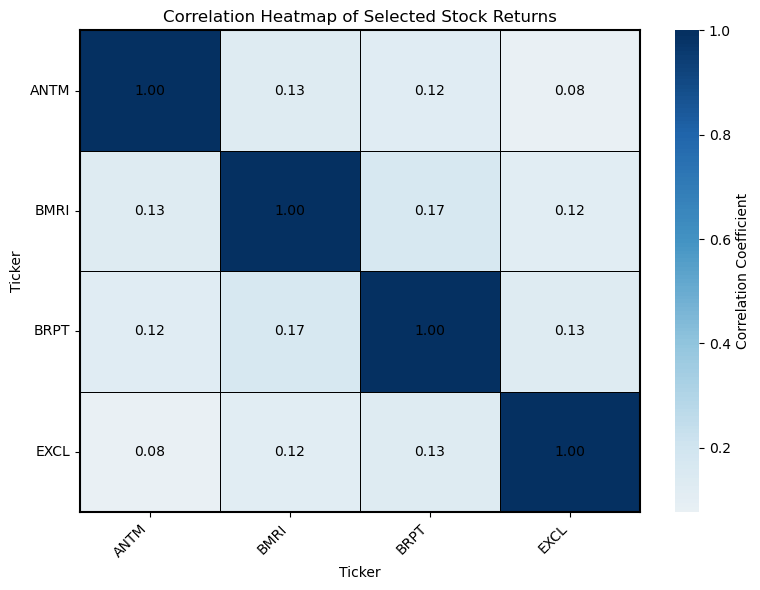

In [65]:
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    corr_matrix,
    cmap="RdBu",
    center=0,
    linewidths=0.5,          # garis antar kotak
    linecolor="black",
    cbar_kws={"label": "Correlation Coefficient"}
)

# ===============================
# ANOTASI MANUAL (angka sudah pasti muncul)
# ===============================
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

# ===============================
# AKTIFKAN GARIS HITAM DI SEMUA TEPI
# ===============================
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

ax.set_title("Correlation Heatmap of Selected Stock Returns", fontsize=12)
ax.set_xlabel("Ticker")
ax.set_ylabel("Ticker")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

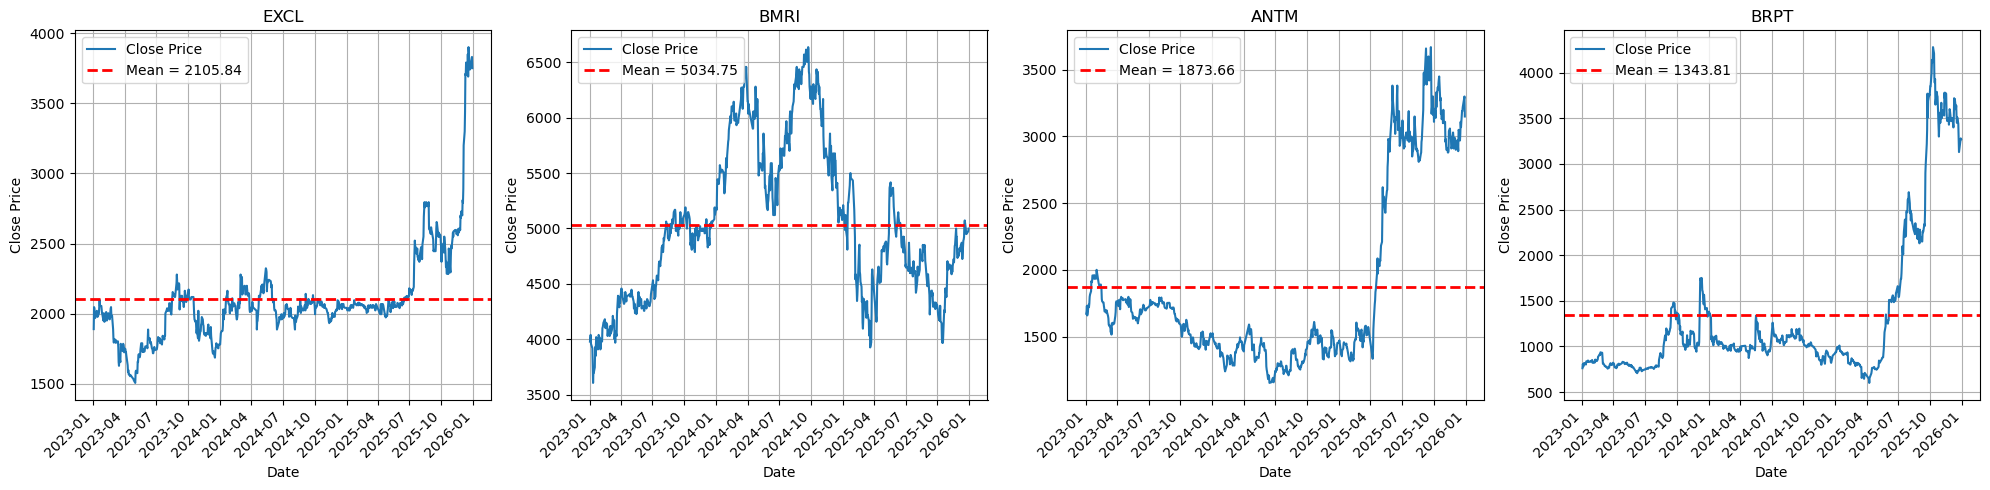

In [67]:
# Pastikan kolom Date menjadi datetime dan index
df_stock_clean['Date'] = pd.to_datetime(df_stock_clean['Date'])
df_stock_clean = df_stock_clean.sort_values('Date')

# Filter data 2025
start_date = '2023-01-01'
end_date = '2025-12-31'
df_2025 = df_stock_clean[(df_stock_clean['Date'] >= start_date) & 
                         (df_stock_clean['Date'] <= end_date)]

# List saham yang terpilih
selected_tickers = best_sharpe['Ticker'].tolist()  # ['EXCL', 'MDKA', 'BRPT', 'ANTM']

# Tentukan jumlah subplot
n_tickers = len(selected_tickers)
fig_cols = n_tickers  # 1 baris, kolom menyesuaikan jumlah saham
fig, axes = plt.subplots(1, fig_cols, figsize=(5*fig_cols, 5), sharex=True)

# Jika hanya 1 saham, axes bukan list, ubah menjadi list
if n_tickers == 1:
    axes = [axes]

# Plot tiap saham
for ax, ticker in zip(axes, selected_tickers):
    series = df_2025[df_2025['Ticker'] == ticker].set_index('Date')['Adj Close']
    mean_price = series.mean()
    
    ax.plot(series.index, series.values, label="Close Price")
    ax.axhline(mean_price, linestyle="--", linewidth=2, color='red',
            label=f"Mean = {mean_price:.2f}")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price")
    ax.legend()

    ax.grid(True)
    
    # Atur x-axis tiap 3 bulan dengan format YYYY-MM
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# MVO

In [43]:
# Pilih saham terbaik hasil clustering
best_tickers = best_sharpe['Ticker'].tolist()
print("Saham terpilih:", best_tickers)

# Pivot log return
log_returns = (
    df_stock_clean
    .loc[df_stock_clean["Ticker"].isin(best_tickers)]
    .pivot(index="Date", columns="Ticker", values="LogReturn")
    .dropna()
)


print("\nDimensi data log return:", log_returns.shape)
print("\n5 Data Pertama Log Return:")
log_returns = log_returns[best_tickers]
log_returns

Saham terpilih: ['EXCL', 'BMRI', 'ANTM', 'BRPT']

Dimensi data log return: (711, 4)

5 Data Pertama Log Return:


Ticker,EXCL,BMRI,ANTM,BRPT
Date,,,,
2023-01-03,0.079692,0.007566,0.010049,0.057154
2023-01-04,-0.004268,0.007510,0.024696,-0.018691
2023-01-05,-0.021598,-0.020151,-0.042349,-0.012666
2023-01-06,-0.013188,-0.002549,0.010126,0.043622
2023-01-09,0.013188,-0.007683,0.037089,-0.006108
...,...,...,...,...
2025-12-22,-0.036558,-0.014598,0.038343,-0.020145
2025-12-23,-0.005333,-0.009852,0.000000,-0.047628
2025-12-24,0.002670,0.000000,0.009360,-0.046810


### MENGHITUNG EXPECTED RETURN & KOVARIANS

In [44]:
TRADING_DAYS = 236

# Return
mu_daily = log_returns.mean()
mu_annual = mu_daily * TRADING_DAYS

print("\nExpected Return Harian:")
print(mu_daily)

print("\nExpected Return Tahunan:")
print(mu_annual)

# Kovarians
cov_daily = log_returns.cov()
cov_annual = cov_daily * TRADING_DAYS

print("\nMatriks Kovarians Harian:")
print(cov_daily)

print("\nMatriks Kovarians Tahunan:")
print(cov_annual)


Expected Return Harian:
Ticker
EXCL    0.000963
BMRI    0.000321
ANTM    0.000891
BRPT    0.002050
dtype: float64

Expected Return Tahunan:
Ticker
EXCL    0.227326
BMRI    0.075646
ANTM    0.210373
BRPT    0.483706
dtype: float64

Matriks Kovarians Harian:
Ticker      EXCL      BMRI      ANTM      BRPT
Ticker                                        
EXCL    0.000448  0.000047  0.000041  0.000109
BMRI    0.000047  0.000372  0.000063  0.000128
ANTM    0.000041  0.000063  0.000651  0.000123
BRPT    0.000109  0.000128  0.000123  0.001578

Matriks Kovarians Tahunan:
Ticker      EXCL      BMRI      ANTM      BRPT
Ticker                                        
EXCL    0.105691  0.011126  0.009737  0.025829
BMRI    0.011126  0.087874  0.014900  0.030281
ANTM    0.009737  0.014900  0.153569  0.029049
BRPT    0.025829  0.030281  0.029049  0.372519


In [45]:
mu_daily

Ticker
EXCL    0.000963
BMRI    0.000321
ANTM    0.000891
BRPT    0.002050
dtype: float64

### FUNGSI PERHITUNGAN PORTOFOLIO

In [46]:
def port_return(weights, mu):
    return weights @ mu

def port_variance(weights, cov):
    return weights.T @ cov @ weights

rf_annual = 0.057291667

def neg_sharpe_ratio(weights, mu, cov, rf):
    ret = port_return(weights, mu)
    vol = np.sqrt(port_variance(weights, cov))
    return - (ret - rf) / vol

print("Fungsi return dan risiko portofolio berhasil didefinisikan.")

Fungsi return dan risiko portofolio berhasil didefinisikan.


### KONDISI DAN KENDALA OPTIMASI

In [47]:
n_assets = len(mu_annual)
x0 = np.ones(n_assets) / n_assets

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 1) for _ in range(n_assets))

print("Jumlah aset:", n_assets)
print("Bobot awal (equal weight):", x0)
print("Kendala: total bobot = 1")
print("Batasan: 0 ≤ w ≤ 1")

Jumlah aset: 4
Bobot awal (equal weight): [0.25 0.25 0.25 0.25]
Kendala: total bobot = 1
Batasan: 0 ≤ w ≤ 1


### OPTIMASI PORTOFOLIO

In [48]:
# ---------------- MAX SHARPE RATIO ----------------
print("\nOptimasi Max Sharpe Ratio...")
res_msr = minimize(
    neg_sharpe_ratio,
    x0,
    args=(mu_annual.values, cov_annual.values, rf_annual),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

w_msr = res_msr.x
print("Status Optimasi MSR:", res_msr.success)
print("Bobot MSR:", w_msr)


# ---------------- GMVP ----------------
print("\nOptimasi Global Minimum Variance...")
res_gmvp = minimize(
    port_variance,
    x0,
    args=(cov_annual.values,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

w_gmvp = res_gmvp.x
print("Status Optimasi GMVP:", res_gmvp.success)
print("Bobot GMVP:", w_gmvp)


# ---------------- TARGET RETURN ----------------
print("\nOptimasi Portofolio dengan Target Return...")

# Tentukan target return = median return saham
target_return = mu_annual.median()
print("Target Return yang digunakan:", target_return)

# Definisikan kendala optimasi
constraints_target = (
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'eq', 'fun': lambda w: port_return(w, mu_annual.values) - target_return}
)

# Lakukan optimasi varians portofolio
res_target = minimize(
    port_variance,
    x0,
    args=(cov_annual.values,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_target
)

# Ambil bobot optimal
w_target = res_target.x

# Tampilkan hasil
print("Status Optimasi Target Return:", res_target.success)
print("Bobot Portofolio Target Return:", w_target)
print("Target Return yang dicapai:", port_return(w_target, mu_annual.values))


Optimasi Max Sharpe Ratio...
Status Optimasi MSR: True
Bobot MSR: [0.4298771  0.         0.23994391 0.33017899]

Optimasi Global Minimum Variance...
Status Optimasi GMVP: True
Bobot GMVP: [0.33998561 0.40084764 0.21434434 0.04482241]

Optimasi Portofolio dengan Target Return...
Target Return yang digunakan: 0.21884960335385614
Status Optimasi Target Return: True
Bobot Portofolio Target Return: [0.38070891 0.25416026 0.23245543 0.13267541]
Target Return yang dicapai: 0.21884960338283427


### RINGKASAN KINERJA PORTOFOLIO

In [49]:
def portfolio_summary(name, weights):
    ret = port_return(weights, mu_annual.values)
    risk = np.sqrt(port_variance(weights, cov_annual.values))
    sharpe = (ret - rf_annual) / risk
    return [name, ret, risk, sharpe]

summary_data = [
    portfolio_summary("Max Sharpe Ratio", w_msr),
    portfolio_summary("Global Minimum Variance", w_gmvp),
    portfolio_summary("Target Return", w_target)
]

summary_df = pd.DataFrame(summary_data, columns=["Portofolio", "Return", "Risiko", "Sharpe"])

print(summary_df)

                Portofolio    Return    Risiko    Sharpe
0         Max Sharpe Ratio  0.307910  0.287971  0.870288
1  Global Minimum Variance  0.174383  0.208772  0.560858
2            Target Return  0.218850  0.218932  0.737936


### TAMPILKAN BOBOT MASING-MASING SAHAM

In [50]:
for name, weights in [
    ("MSR", w_msr),
    ("GMVP", w_gmvp),
    ("Target", w_target)
]:
    print(f"\nBobot Portofolio {name}")
    weights_df = pd.DataFrame({
        "Saham": log_returns.columns,
        "Bobot": weights
    })
    print(weights_df)


Bobot Portofolio MSR
  Saham     Bobot
0  EXCL  0.429877
1  BMRI  0.000000
2  ANTM  0.239944
3  BRPT  0.330179

Bobot Portofolio GMVP
  Saham     Bobot
0  EXCL  0.339986
1  BMRI  0.400848
2  ANTM  0.214344
3  BRPT  0.044822

Bobot Portofolio Target
  Saham     Bobot
0  EXCL  0.380709
1  BMRI  0.254160
2  ANTM  0.232455
3  BRPT  0.132675


### VISUALISASI ALOKASI BOBOT

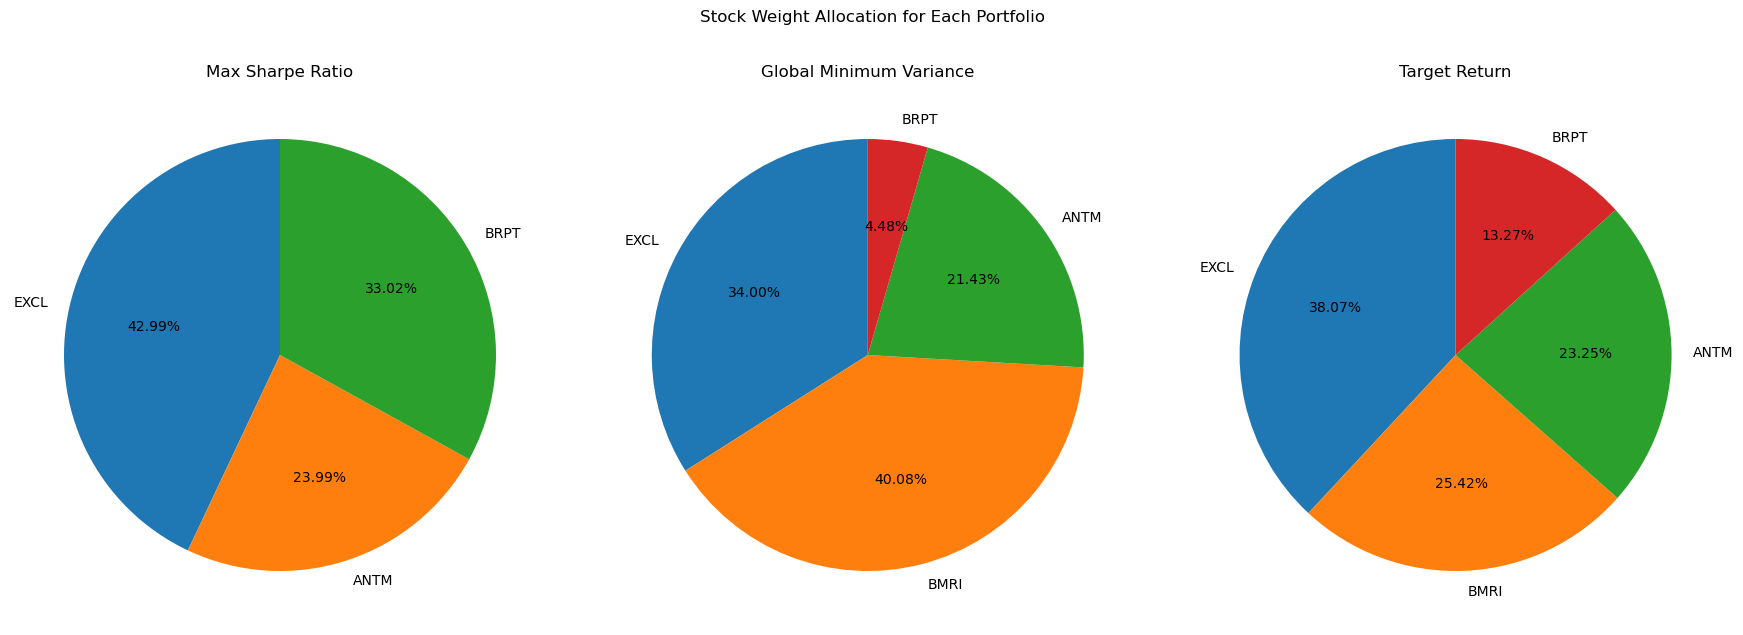

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

portfolios = [
    ("Max Sharpe Ratio", w_msr),
    ("Global Minimum Variance", w_gmvp),
    ("Target Return", w_target)
]

for ax, (name, weights) in zip(axes, portfolios):
    positive = weights > 0
    ax.pie(
        weights[positive],
        labels=np.array(mu_annual.index)[positive],
        autopct='%.2f%%',
        startangle=90
    )
    ax.set_title(name)

plt.suptitle("Stock Weight Allocation for Each Portfolio", y=1.05)
plt.tight_layout()
plt.show()

# VaR

### Return Portofolio Harian

In [52]:
log_returns

Ticker,EXCL,BMRI,ANTM,BRPT
Date,,,,
2023-01-03,0.079692,0.007566,0.010049,0.057154
2023-01-04,-0.004268,0.007510,0.024696,-0.018691
2023-01-05,-0.021598,-0.020151,-0.042349,-0.012666
2023-01-06,-0.013188,-0.002549,0.010126,0.043622
2023-01-09,0.013188,-0.007683,0.037089,-0.006108
...,...,...,...,...
2025-12-22,-0.036558,-0.014598,0.038343,-0.020145
2025-12-23,-0.005333,-0.009852,0.000000,-0.047628
2025-12-24,0.002670,0.000000,0.009360,-0.046810


### Return harian masing-masing portofolio

In [53]:
port_returns = {
    "Max Sharpe Ratio": log_returns @ w_msr,
    "Global Minimum Variance": log_returns @ w_gmvp,
    "Target Return": log_returns @ w_target
}

In [54]:
# Gabungkan ke dalam satu DataFrame
df_port_returns = pd.DataFrame(port_returns)

# Pastikan index berupa datetime
df_port_returns.index = pd.to_datetime(df_port_returns.index)

# Tampilkan 5 data pertama
print("\n Return Harian Tiga Portofolio")
df_port_returns


 Return Harian Tiga Portofolio


,Max Sharpe Ratio,Global Minimum Variance,Target Return
Date,,,
2023-01-03,0.055540,0.034843,0.042181
2023-01-04,-0.002080,0.006015,0.003545
2023-01-05,-0.023628,-0.025066,-0.024869
2023-01-06,0.011163,-0.001380,0.002473
2023-01-09,0.012552,0.009080,0.010879
...,...,...,...
2025-12-22,-0.013166,-0.010965,-0.011388
2025-12-23,-0.018018,-0.007897,-0.010854
2025-12-24,-0.012062,0.000816,-0.003018


### Statistika Deskriptif

In [55]:
stats_results = []

for name, returns in port_returns.items():
    
    desc = returns.describe()
    
    stats_results.append({
        "Portofolio": name,
        "Mean": desc["mean"],
        "Std_Dev": desc["std"],
        "Minimum": desc["min"],
        "Maximum": desc["max"],
        "Skewness": skew(returns),
        "Kurtosis": kurtosis(returns, fisher=True)  # excess kurtosis
    })

df_stats = pd.DataFrame(stats_results)

print("\n Statistik Deskriptif dan Karakteristik Distribusi")
df_stats


 Statistik Deskriptif dan Karakteristik Distribusi


,Portofolio,Mean,Std_Dev,Minimum,Maximum,Skewness,Kurtosis
0,Max Sharpe Ratio,0.001305,0.018745,-0.084288,0.085248,0.009522,2.549084
1,Global Minimum Variance,0.000739,0.013590,-0.092798,0.055803,-0.450933,4.159573
2,Target Return,0.000927,0.014251,-0.089729,0.056361,-0.358090,3.398906


### Fungsi Historical Simulation

In [56]:
def historical_var(returns, cl, h):
    percentile = np.percentile(returns, 100 * (1 - cl))
    return -percentile * np.sqrt(h)

In [57]:
# Ambil return salah satu portofolio
returns_msr = port_returns["Max Sharpe Ratio"]

# Urutkan dari terkecil ke terbesar (ascending)
sorted_returns = np.sort(returns_msr)
df_sorted = pd.DataFrame(sorted_returns, columns=["Sorted_Return"])
df_sorted.head(35)   # lihat 15 return terburuk


,Sorted_Return
0,-0.084288
1,-0.081950
2,-0.066985
3,-0.062268
4,-0.055013
5,-0.054738
6,-0.052699
7,-0.051946
8,-0.050040
9,-0.044985


### Fungsi Cornish–Fisher Expansion

In [58]:
def cornish_fisher_var(returns, cl, h):
    mean = np.mean(returns)
    std = np.std(returns, ddof=1)
    s = skew(returns)
    k = kurtosis(returns, fisher=True)
    
    z = norm.ppf(1 - cl)
    z_cf = (z 
            + (1/6)*(z**2 - 1)*s
            + (1/24)*(z**3 - 3*z)*k
            - (1/36)*(2*z**3 - 5*z)*(s**2))
    
    var_daily = mean + z_cf * std
    return -var_daily * np.sqrt(h)

### Parameter

In [59]:
confidence_levels = [0.90, 0.95, 0.99]
holding_days = [1, 2, 3]

### Perhitungan VaR

In [60]:
VaR_results = []

for name, returns in port_returns.items():
    for h in holding_days:
        for cl in confidence_levels:
            VaR_results.append({
                "Portofolio": name,
                "Holding_Days": h,
                "Confidence_Level": cl,
                "Historical Simulation": round(historical_var(returns, cl, h), 6),
                "Cornish-Fisher": round(cornish_fisher_var(returns, cl, h), 6)
            })

df_VaR = pd.DataFrame(VaR_results)

# Urutkan agar sistematis
df_VaR = df_VaR.sort_values(
    by=["Portofolio", "Holding_Days", "Confidence_Level"]
).reset_index(drop=True)

print("\n Value at Risk – Semua Portofolio")
df_VaR


 Value at Risk – Semua Portofolio


,Portofolio,Holding_Days,Confidence_Level,Historical Simulation,Cornish-Fisher
0,Global Minimum Variance,1,0.90,0.014583,0.013404
1,Global Minimum Variance,1,0.95,0.020802,0.022164
2,Global Minimum Variance,1,0.99,0.030637,0.047558
3,Global Minimum Variance,2,0.90,0.020623,0.018956
4,Global Minimum Variance,2,0.95,0.029418,0.031344
5,Global Minimum Variance,2,0.99,0.043327,0.067257
6,Global Minimum Variance,3,0.90,0.025258,0.023217
7,Global Minimum Variance,3,0.95,0.036029,0.038389
8,Global Minimum Variance,3,0.99,0.053065,0.082372
9,Max Sharpe Ratio,1,0.90,0.019298,0.019235


In [61]:
# Bulatkan 4 angka belakang koma
df_VaR["Historical Simulation"] = df_VaR["Historical Simulation"].round(4)
df_VaR["Cornish-Fisher"] = df_VaR["Cornish-Fisher"].round(4)

# Urutkan: Portofolio → Confidence Level → Holding Days
df_VaR = df_VaR.sort_values(
    by=["Portofolio", "Confidence_Level", "Holding_Days"]
)

# Tampilkan per portofolio
for name, group in df_VaR.groupby("Portofolio"):
    print(f"\n===== {name} =====")
    
    # Drop kolom Portofolio agar tidak ikut di baris
    display(
        group.drop(columns=["Portofolio"])
             .reset_index(drop=True)
    )


===== Global Minimum Variance =====


,Holding_Days,Confidence_Level,Historical Simulation,Cornish-Fisher
0,1,0.90,0.0146,0.0134
1,2,0.90,0.0206,0.0190
2,3,0.90,0.0253,0.0232
3,1,0.95,0.0208,0.0222
4,2,0.95,0.0294,0.0313
5,3,0.95,0.0360,0.0384
6,1,0.99,0.0306,0.0476
7,2,0.99,0.0433,0.0673
8,3,0.99,0.0531,0.0824



===== Max Sharpe Ratio =====


,Holding_Days,Confidence_Level,Historical Simulation,Cornish-Fisher
0,1,0.90,0.0193,0.0192
1,2,0.90,0.0273,0.0272
2,3,0.90,0.0334,0.0333
3,1,0.95,0.0277,0.0285
4,2,0.95,0.0392,0.0403
5,3,0.95,0.0480,0.0494
6,1,0.99,0.0518,0.0533
7,2,0.99,0.0732,0.0754
8,3,0.99,0.0896,0.0924



===== Target Return =====


,Holding_Days,Confidence_Level,Historical Simulation,Cornish-Fisher
0,1,0.90,0.0151,0.0145
1,2,0.90,0.0213,0.0205
2,3,0.90,0.0261,0.0251
3,1,0.95,0.0213,0.0230
4,2,0.95,0.0302,0.0325
5,3,0.95,0.0370,0.0398
6,1,0.99,0.0364,0.0466
7,2,0.99,0.0514,0.0659
8,3,0.99,0.0630,0.0807


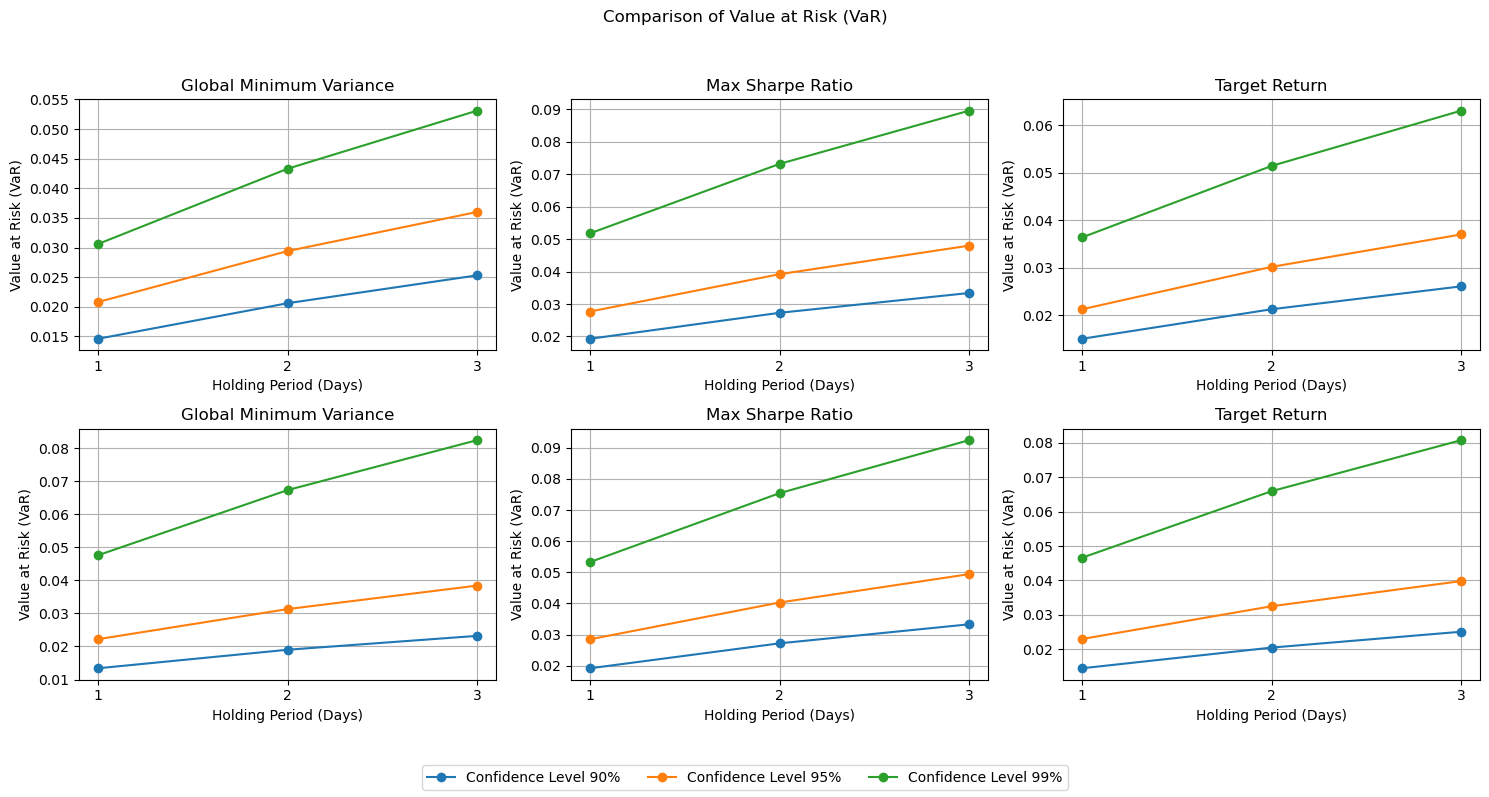

In [69]:
df_plot = df_VaR.copy()
df_plot["Historical Simulation"] = df_plot["Historical Simulation"].abs()
df_plot["Cornish-Fisher"] = df_plot["Cornish-Fisher"].abs()

# Filter hanya periode 1, 2, 3 hari
df_plot = df_plot[df_plot["Holding_Days"].isin([1, 2, 3])]

portfolios = df_plot["Portofolio"].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, portfolio in enumerate(portfolios):
    
    data_port = df_plot[df_plot["Portofolio"] == portfolio]
    
    # Historical Simulation
    for cl in sorted(data_port["Confidence_Level"].unique()):
        subset = data_port[data_port["Confidence_Level"] == cl]
        
        axes[0, i].plot(
            subset["Holding_Days"],
            subset["Historical Simulation"],
            marker='o',
            label=f"Confidence Level {int(cl*100)}%"
        )
    
    axes[0, i].set_title(f"{portfolio}")
    axes[0, i].set_xlabel("Holding Period (Days)")
    axes[0, i].set_ylabel("Value at Risk (VaR)")
    axes[0, i].set_xticks([1, 2, 3])
    axes[0, i].grid(True)
    
    
    # Cornish-Fisher
    for cl in sorted(data_port["Confidence_Level"].unique()):
        subset = data_port[data_port["Confidence_Level"] == cl]
        
        axes[1, i].plot(
            subset["Holding_Days"],
            subset["Cornish-Fisher"],
            marker='o',
            label=f"Confidence Level {int(cl*100)}%"
        )
    
    axes[1, i].set_title(f"{portfolio}")
    axes[1, i].set_xlabel("Holding Period (Days)")
    axes[1, i].set_ylabel("Value at Risk (VaR)")
    axes[1, i].set_xticks([1, 2, 3])
    axes[1, i].grid(True)


handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)

plt.suptitle("Comparison of Value at Risk (VaR)", y=0.98)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()